<a href="https://colab.research.google.com/github/sap156/infinityskillshub/blob/main/Query_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative AI for Data Professionals
# Data Querying, Analysis and Optimization — Module 4 Part 2
# Query Optimization

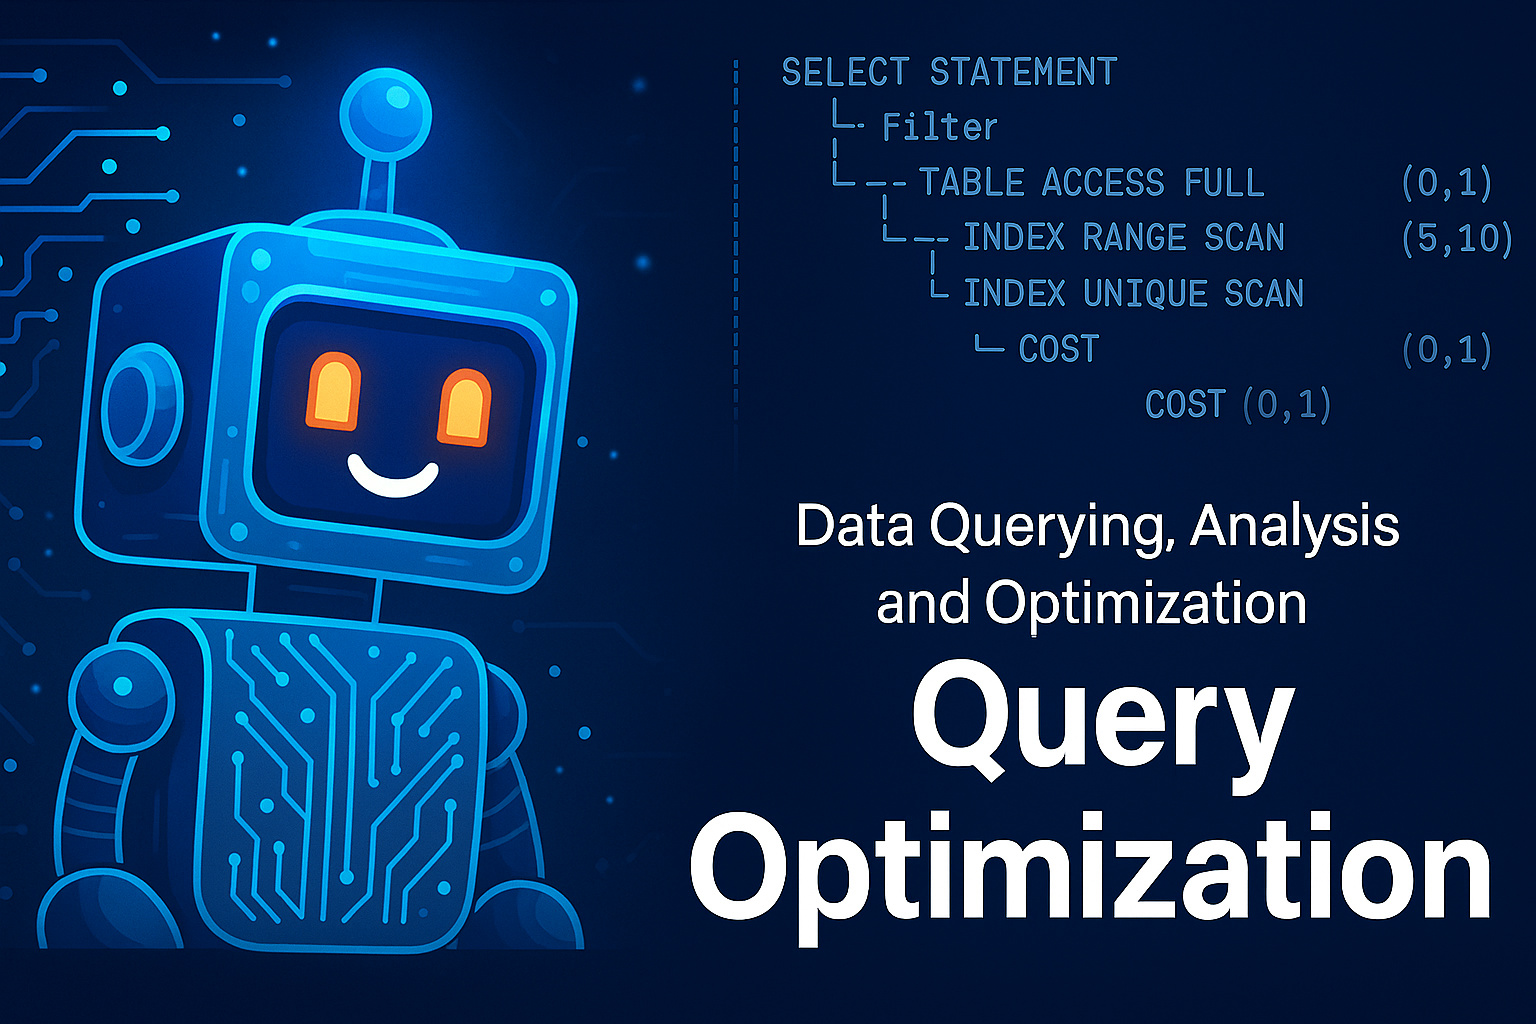

# ⚡ Query Optimization with Generative AI

**Query optimization is a crucial skill for data engineers, especially when dealing
with large datasets.** Writing efficient SQL queries can significantly improve query
performance and reduce computing costs. However, optimizing SQL queries can be complex,
requiring deep knowledge of indexing, joins, and execution plans.

Generative AI can assist in **query optimization and cleaning** by:
* Identifying inefficiencies in SQL queries.
* Suggesting alternative approaches, such as **converting subqueries to joins**.
* Rewriting complex queries into **readable, modular** steps.

In this article, we'll explore how generative AI can help refine SQL queries for
better performance and readability.

**Learning Objectives:**
- ✅ Optimize SQL queries by converting subqueries to joins
- ✅ Clean and refactor complex nested queries for readability
- ✅ Use AI to identify performance bottlenecks automatically
- ✅ Split complex queries into maintainable steps with temp tables
- ✅ Build AI-powered query optimization workflows


In [ ]:
# =====================================================
# 🛠️ SETUP AND IMPORTS
# =====================================================

from openai import OpenAI
import pandas as pd
import json
import numpy as np
from pprint import pprint
from google.colab import userdata

api_key=userdata.get('OPENAI_API_KEY')

# Set up our AI client securely
client = OpenAI(api_key=api_key)

def clean(dict_variable):
    return next(iter(dict_variable.values()))

print("✅ Environment ready for SQL query optimization!")

# =====================================================
# ⚡ OPTIMIZING SQL QUERIES FOR PERFORMANCE
# =====================================================


## 1. Optimizing SQL Queries for Performance

**Example 1: Converting a Subquery to an Optimized Join**

Subqueries can be inefficient, especially when they involve filtering on large tables.
Consider the following query:

```sql
SELECT *
FROM orders
WHERE order_date > '2025-06-13'
AND customer_id IN (
    SELECT customer_id FROM customers WHERE country = 'USA'
);
```

This query uses a **subquery**, which can be inefficient if the `customers` table
is large. A better approach is to **use a join** to filter results more efficiently.

**Using Generative AI to Optimize the Query**

We can ask an LLM to optimize this query automatically.

In [ ]:
bad_query = """
SELECT * FROM orders WHERE order_date > '2025-06-13' AND customer_id IN (SELECT customer_id FROM customers WHERE country = 'USA')
"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a SQL expert. Optimize SQL queries based on natural language descriptions."},
        {"role": "user", "content": "Optimize this SQL query and output in plain text form: {} Optimization goal: Improve performance for a large dataset.".format(bad_query)}
    ],

)

print (response.choices[0].message.content)

To optimize the SQL query, we can use a JOIN instead of a subquery because JOINs are generally more efficient when dealing with large datasets. Additionally, we can limit the number of columns returned instead of using SELECT * to reduce the amount of data processed and transferred.

Here is the optimized SQL query:

```sql
SELECT o.*
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_date > '2025-06-13'
AND c.country = 'USA';
```

This query retrieves only the relevant orders from customers in the USA that were placed after the specified date, improving performance by leveraging the JOIN operation. If appropriate indexes are in place on `orders.order_date` and `customers.country`, further performance improvements can be achieved.


# =====================================================
# 🧹 CLEANING AND REFACTORING SQL QUERIES
# =====================================================


## 2. Cleaning and Refactoring SQL Queries

Readable queries are easier to debug, maintain, and optimize. Generative AI can help
**split complex SQL queries into multiple steps**, using **temporary tables** for clarity.

**Example 2: Cleaning a Nested Query**

Consider the following **hard-to-read** SQL query: It retrieves records of active employees whose sales amount (amt) is higher than the average sales amount.

```sql
SELECT *
FROM (
    SELECT c3.id, c3.date, c3.amt, c3.prod_name, c3.region, e.emp_name
    FROM region c3
    JOIN employees e ON c3.id = e.id
    WHERE e.active = 1
) AS subquery
JOIN (
    SELECT AVG(s.amt) AS avg_amt
    FROM sales s
) AS subquery2 ON subquery.amt > subquery2.avg_amt;
```

**Using Generative AI to Improve Readability**

We can instruct the AI to **split this query into multiple steps** for better readability.


In [ ]:
bad_query = """
SELECT *
FROM (
    SELECT c3.id, c3.date, c3.amt, c3.prod_name, c3.region, e.emp_name
    FROM region c3
    JOIN employees e ON c3.id = e.id
    WHERE e.active = 1
) AS subquery
JOIN (
    SELECT AVG(s.amt) AS avg_amt
    FROM sales s
) AS subquery2 ON subquery.amt > subquery2.avg_amt;"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a SQL expert. Given a SQL query, make it more readable. You may split the query into multiple steps with temp tables, and add naming conventions / column names."},
        {"role": "user", "content": "Make this SQL query more readable. Use temporary tables if needed. Output in JSON form: {}".format(bad_query)}
    ],
    response_format={"type": "json_object"}
)

optimized_steps = json.loads(response.choices[0].message.content)

optimized_steps

**Key Benefits of Using AI for Query Optimization**

* **Performance Gains**: Optimizing queries helps reduce database load and execution time.
* **Readability**: Breaking complex queries into steps improves clarity.
* **Maintainability**: Refactored queries are easier to debug and modify.
* **Adaptability**: AI can adjust queries dynamically based on schema changes.

# =====================================================
# 🎯 CONCLUSION
# =====================================================


## Conclusion

Generative AI is **revolutionizing SQL query optimization**. Whether you're optimizing
performance-heavy queries or simply making them more readable, AI can save data
engineers significant time and effort.